In [1]:
print('Hello World')

Hello World


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
print(f'Версися Pandas: {pd.__version__}')
print(f'Версися Numpy: {np.__version__}')

Версися Pandas: 2.2.2
Версися Numpy: 2.0.2


In [4]:
import tensorflow as tf

In [83]:
from tensorflow.keras.layers import Input, Dense, Add, Normalization
from tensorflow.keras.optimizers import SGD, Adam

In [98]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [5]:
print(f'Версися Tensorflow: {tf.__version__}')

Версися Tensorflow: 2.19.0


In [6]:
titanic_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/python_spbu_3 : 09.10.2025/titanik.csv'

In [7]:
housing_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/python_spbu_3 : 09.10.2025/housing.csv'

In [8]:
titanic_df = pd.read_csv(titanic_path)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
housing_df = pd.read_csv(housing_path, sep='.')
housing_df.head()

,0,00632 18,00 2,310 0 0,5380 6,5750 65,20 4,0900 1 296,0 15,30 396,90 4,98 24,00
0,0,02731 0,00 7,070 0 0,4690 6,4210 78,90 4,9671 2 242,0 17,80 396,90 9,14 21,60
1,0,02729 0,00 7,070 0 0,4690 7,1850 61,10 4,9671 2 242,0 17,80 392,83 4,03 34,70
2,0,03237 0,00 2,180 0 0,4580 6,9980 45,80 6,0622 3 222,0 18,70 394,63 2,94 33,40
3,0,06905 0,00 2,180 0 0,4580 7,1470 54,20 6,0622 3 222,0 18,70 396,90 5,33 36,20
4,0,02985 0,00 2,180 0 0,4580 6,4300 58,70 6,0622 3 222,0 18,70 394,12 5,21 28,70


In [10]:
from tensorflow.keras.layers import Dense

In [11]:
x = np.ones((4, 3))
x

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [12]:
dense_layer = Dense(units=2, input_shape=(3,))
dense_layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense, built=False>

In [13]:
output = dense_layer(x)
print(output)

tf.Tensor(
[[1.538248  0.7204722]
 [1.538248  0.7204722]
 [1.538248  0.7204722]
 [1.538248  0.7204722]], shape=(4, 2), dtype=float32)


In [14]:
model = tf.keras.Sequential()

In [15]:
model.add(Dense(10, input_shape=(10,), activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393 (1.54 KB)

 Trainable params: 393 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

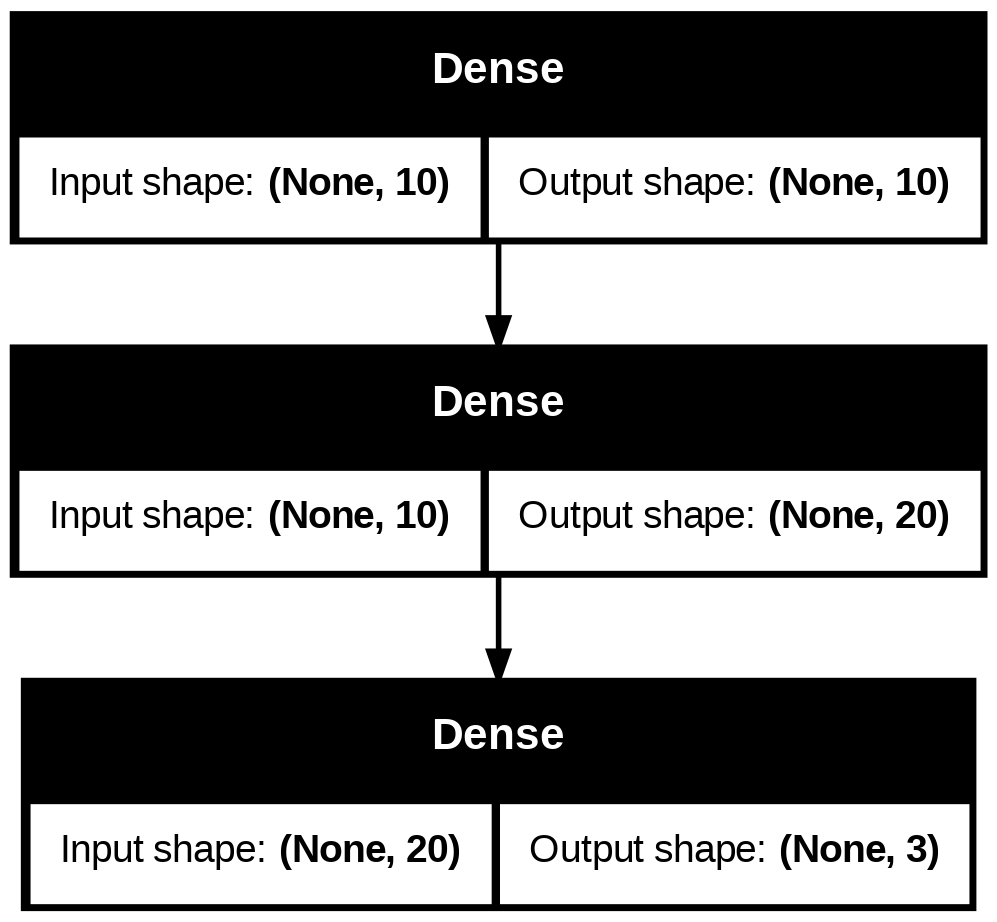

In [17]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [18]:
input_layer = tf.keras.layers.Input(shape=(10,), name='Input')

In [19]:
L1 = tf.keras.layers.Dense(10, name='Layer1')
L1_output = L1(input_layer)

In [20]:
L2 = tf.keras.layers.Dense(10, name='Layer2')(input_layer)
L3 = tf.keras.layers.Dense(10, name='Layer3')(L2)
L4 = tf.keras.layers.Dense(10, name='Layer4')(L3)
L5 = tf.keras.layers.Dense(10, name='Layer5')(L2)

In [21]:
sum_output = tf.keras.layers.Add(name='SumLayer')([L1_output, L4, L5])
output = tf.keras.layers.Dense(10, name = 'Output')(sum_output)

In [22]:
sum_output = tf.keras.layers.Add(name='SumLayer')([L1_output, L4, L5])
output = tf.keras.layers.Dense(10, name = 'Output')(sum_output)

In [23]:
model = tf.keras.Model(inputs=input_layer, outputs=output)

In [25]:
x = np.linspace(-3, 3, 1000).reshape(-1, 1)

In [27]:
x.shape

(1000, 1)

In [26]:
f = np.vectorize(lambda x: 2*x+5)
y = f(x)

In [28]:
model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,), activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
sgd = SGD(learning_rate=0.01, nesterov=True, momentum=0.9)

In [60]:
model.compile(loss='mean_squared_error', optimizer=sgd)

In [61]:
model.fit(x, y, epochs=10, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


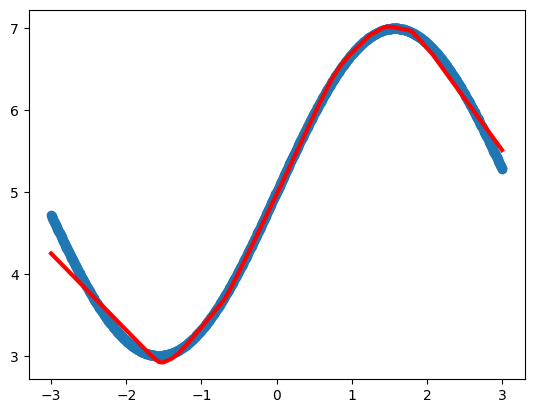

In [62]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=3)
plt.show()

In [68]:
f = np.vectorize(lambda x: 2*np.sin(x) + 5)
y = f(x)

In [69]:
model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,), activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model.compile(loss='mean_squared_error', optimizer='sgd')

In [71]:
model.fit(x, y, epochs=10, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


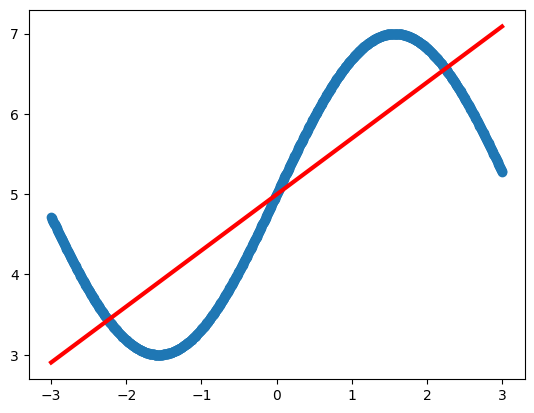

In [72]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=3)
plt.show()

In [46]:
model = tf.keras.Sequential()
model.add(Dense(100, input_shape=(1,), activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.compile(loss='mean_squared_error', optimizer='sgd')

In [48]:
model.fit(x, y, epochs=10, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


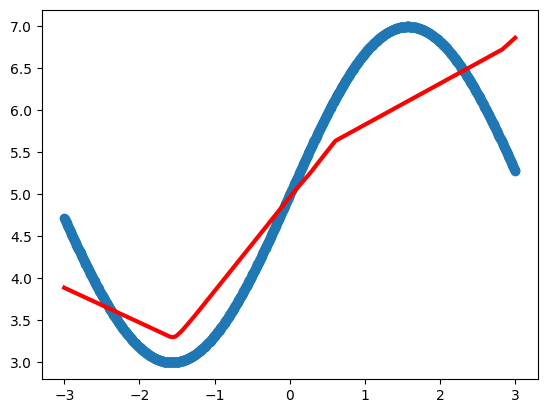

In [49]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=3)
plt.show()

# Регрессия

In [74]:
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
         'AFE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [75]:
housing_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/python_spbu_3 : 09.10.2025/housing.csv'

In [78]:
df = pd.read_csv(housing_path,sep = '\s+', names=names)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4043607429.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(housing_path,sep = '\s+', names=names)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AFE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [79]:
train_dataset = df.sample(frac=0.8, random_state=0)
test_dataset = df.drop(train_dataset.index)

In [80]:
train_dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AFE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
329,0.06724,0.0,3.24,0,0.460,6.333,17.2,5.2146,4,430.0,16.9,375.21,7.34,22.6
371,9.23230,0.0,18.10,0,0.631,6.216,100.0,1.1691,24,666.0,20.2,366.15,9.53,50.0
219,0.11425,0.0,13.89,1,0.550,6.373,92.4,3.3633,5,276.0,16.4,393.74,10.50,23.0
403,24.80170,0.0,18.10,0,0.693,5.349,96.0,1.7028,24,666.0,20.2,396.90,19.77,8.3
78,0.05646,0.0,12.83,0,0.437,6.232,53.7,5.0141,5,398.0,18.7,386.40,12.34,21.2


In [81]:
x_train = train_dataset.copy()
x_test = test_dataset.copy()

In [82]:
y_train = x_train.pop('MEDV')
y_test = x_test.pop('MEDV')

In [84]:
# Проводоим нормализацию данных
normalizer = Normalization() # axis=-1
normalizer.adapt(np.array(x_train))

In [85]:
linear_model = tf.keras.Sequential([
    normalizer,
    Dense(1, activation='linear')
])

In [86]:
linear_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (405, 13)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (112.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27 (112.00 B)

In [87]:
linear_model.compile(
    optimizer= Adam(learning_rate=0.1),
    loss='mean_squared_error'
)

In [89]:
linear_model.fit(x_train, y_train, epochs=100, verbose=0, validation_split=0.2)

In [90]:
linear_model.evaluate(x_test, y_test, verbose=0)

16.23024559020996

In [92]:
linear_model = tf.keras.Sequential([
    normalizer,
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

In [93]:
linear_model.compile(
    optimizer= Adam(learning_rate=0.1),
    loss='mean_squared_error'
)

In [94]:
linear_model.fit(x_train, y_train, epochs=100, verbose=0, validation_split=0.2)

In [95]:
linear_model.evaluate(x_test, y_test, verbose=0)

13.54147720336914

# Классификация

In [100]:
iris = load_iris()
X, y = iris.data, iris.target

In [102]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
model = tf.keras.Sequential([
    Dense(64, input_shape=(4,), activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [108]:
model.fit(x_train, y_train, epochs=100,
          validation_data = (x_test, y_test))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.3729 - loss: 1.0281 - val_accuracy: 0.4000 - val_loss: 0.9115
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5419 - loss: 0.9036 - val_accuracy: 0.7000 - val_loss: 0.8571
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6675 - loss: 0.8579 - val_accuracy: 0.7000 - val_loss: 0.8199
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6394 - loss: 0.8386 - val_accuracy: 0.7000 - val_loss: 0.7956
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7346 - loss: 0.7902 - val_accuracy: 0.9667 - val_loss: 0.7698
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9235 - loss: 0.7628 - val_accuracy: 0.9333 - val_loss: 0.7387
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9417 - loss: 0.7285 - val_accuracy: 0.9333 - val_loss: 0.7117
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9623 - loss: 0.7167 - val_accuracy: 0.9333 - val_loss:

In [109]:
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9667 - loss: 0.1170


[0.11702362447977066, 0.9666666388511658]

In [111]:
model.save('iris.keras', overwrite=True, include_optimizer=True)

In [112]:
model_new = tf.keras.models.load_model('iris.keras')

In [113]:
model_new.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9667 - loss: 0.1170


[0.11702362447977066, 0.9666666388511658]

In [120]:
titanic_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/python_spbu_3 : 09.10.2025/titanik.csv'

In [121]:
df = pd.read_csv(titanic_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [122]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

In [123]:
df['Embarked'] = df['Embarked'].fillna('U')
df['Embarked'] = df['Embarked'].map({'U': 0, 'S': 1, 'C': 2, 'Q': 3})
df['Embarked'] = df['Embarked'].astype('Int64')

In [124]:
df['Sex'] = np.where(df['Sex'] == 'female', 1, 0)
df['Age'] = df['Age'].fillna(29)

In [125]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
817,0,2,0,31.0,1,1,37.0042,2
619,0,2,0,26.0,0,0,10.5000,1
872,0,1,0,33.0,0,0,5.0000,1
383,1,1,1,35.0,1,0,52.0000,1
651,1,2,1,18.0,0,1,23.0000,1


In [128]:
X = df.drop(columns=['Survived'], axis=1)
y = df['Survived']

In [129]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
x_train.shape

(712, 7)

In [137]:
model = tf.keras.Sequential([
    Dense(14, input_shape=(7,), activation='relu'),
    Dense(28, input_shape=(7,), activation='relu'),
    Dense(56, input_shape=(7,), activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 56)             │         1,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.64 KB)

 Trainable params: 2,213 (8.64 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['precision'])

In [140]:
model.fit(x_train, y_train, epochs=150, batch_size=64, callbacks=[checkpoint],
          validation_data = (x_test, y_test))

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 1.0530 - precision: 0.4190 - val_loss: 0.9004 - val_precision: 1.0000
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7829 - precision: 0.6728 - val_loss: 0.6109 - val_precision: 0.8571
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6230 - precision: 0.5710 - val_loss: 0.5532 - val_precision: 0.7907
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5797 - precision: 0.7438 - val_loss: 0.5527 - val_precision: 0.8182
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5800 - precision: 0.6933 - val_loss: 0.5323 - val_precision: 0.8000
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5674 - precision: 0.7287 - val_loss: 0.5141 - val_precision: 0.7313
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5581 - precision: 0.7599 - val_loss: 0.4952 - val_precision: 0.8889
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5324 - precision: 0.7571 - v

In [141]:
model.evaluate(x_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4123 - precision: 0.8726 


[0.4112398326396942, 0.8474576473236084]

In [136]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('titanik.keras',
                                                monitor = 'val_loss',
                                                save_best_only = True,
                                                mode = 'min')

In [143]:
model_new = tf.keras.models.load_model('titanik.keras')
model_new.evaluate(x_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4098 - precision: 0.8726  


[0.40832972526550293, 0.8474576473236084]

In [145]:
model_new.fit(
    x_train, y_train, epochs=300, initial_epoch =150, batch_size=64, callbacks=[checkpoint],
          validation_data = (x_test, y_test)
)

Epoch 151/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3531 - precision: 0.8202 - val_loss: 0.4511 - val_precision: 0.7846
Epoch 152/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3820 - precision: 0.8442 - val_loss: 0.5056 - val_precision: 0.7123
Epoch 153/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4018 - precision: 0.7953 - val_loss: 0.4377 - val_precision: 0.8125
Epoch 154/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3895 - precision: 0.8352 - val_loss: 0.4592 - val_precision: 0.8644
Epoch 155/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4098 - precision: 0.8620 - val_loss: 0.4773 - val_precision: 0.7536
Epoch 156/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3761 - precision: 0.8583 - val_loss: 0.4269 - val_precision: 0.8125
Epoch 157/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3595 - precision: 0.8667 - val_loss: 0.4481 - val_precision: 0.8000
Epoch 158/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3654 - precis

In [146]:
model_new.evaluate(x_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5049 - precision: 0.8715 


[0.478064626455307, 0.8448275923728943]

In [147]:
model_new_v2 = tf.keras.models.load_model('titanik.keras')
model_new_v2.evaluate(x_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4015 - precision: 0.8258  


[0.4055127501487732, 0.8064516186714172]